In [61]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta
from matplotlib import cm
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap
import geopandas as gpd
from shapely.validation import make_valid
from matplotlib.cm import get_cmap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.transforms as mtransforms
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


# --- Configuration ---
path_to_save_images = '/home/abhis/india_power/images'
path_to_input       = '/home/abhis/india_power/gridpath_india_viz/processed_data/'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs/'
path_to_images      = '/home/gterren/india_power/images/'

scenario = 'ra-8_prm_90_ccap'

In [3]:
df_system_lolev_filtered = pd.read_csv(path_to_input+f'system_lolev-{scenario}.csv')
print(df_system_lolev_filtered.shape)

(112, 6)


In [46]:

print(max(df_system_lolev_filtered['peak_unserved_energy']))
print(max(df_system_lolev_filtered['unserved_energy']))
print(min(df_system_lolev_filtered['peak_unserved_energy']))
print(min(df_system_lolev_filtered['unserved_energy']))

x_ = np.linspace(1000, 25000, num = 15)
y_ = np.linspace(1000, 45000, num = 15)
print(x_)
print(y_)

Z_ = np.zeros((len(x_), len(y_)))

for _, row in df_system_lolev_filtered.iterrows():
    i = np.argsort(np.abs(x_ - row['peak_unserved_energy']))[0]
    j = np.argsort(np.abs(y_ - row['unserved_energy']))[0]
    Z_[i, j] += 1

print(Z_)
print((Z_.sum()))

44969.51260610838
44969.51260610838
2.3598921200662497
2.3598921200662497
[ 1000.          2714.28571429  4428.57142857  6142.85714286
  7857.14285714  9571.42857143 11285.71428571 13000.
 14714.28571429 16428.57142857 18142.85714286 19857.14285714
 21571.42857143 23285.71428571 25000.        ]
[ 1000.          4142.85714286  7285.71428571 10428.57142857
 13571.42857143 16714.28571429 19857.14285714 23000.
 26142.85714286 29285.71428571 32428.57142857 35571.42857143
 38714.28571429 41857.14285714 45000.        ]
[[58.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 4.  7.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  7.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  4.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  3.  0.  0.  0.  0.  0.

/tmp/ipykernel_4130169/2390145520.py:15: RuntimeWarning: divide by zero encountered in log
  Z_log = np.log(Z_)


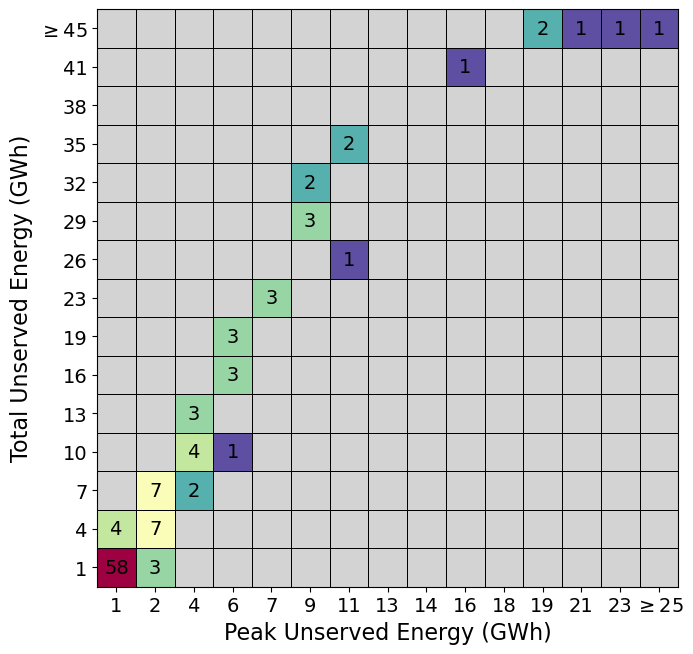

In [ ]:
units = 1e3
# Get a colormap and set color for masked values
# Get a colormap and customize NaN color
W_ = np.around(Z_, decimals=0)
#W_ = np.around(Z_/18., decimals=2) 

_cmap = plt.cm.Spectral_r
_cmap.set_bad(color='white')  # set color for NaN or masked regions

plt.figure(figsize=(7.5, 5))
# plt.imshow(Z_, origin='lower', extent=(x_[0], x_[-1], y_[0], y_[-1]), aspect='auto', cmap=_cmap)
# plt.imshow(np.log(Z_), origin='lower', extent=(x_[0], x_[-1], y_[0], y_[-1]), aspect='auto', cmap=_cmap)
# plt.imshow(np.log(Z_), origin='lower', extent=(0, x_[-1], 0, y_[-1]), aspect='auto', cmap=_cmap)

Z_log = np.log(Z_)
Z_log = np.ma.masked_invalid(Z_log)  # masks -inf, inf, nan

_cmap = _cmap.copy()
_cmap.set_bad(color="lightgray")  # color for masked values


plt.pcolormesh(x_, y_, Z_log, edgecolors='k', linewidth=.7, cmap=_cmap)

for i in range(W_.shape[0]):       # rows
    for j in range(W_.shape[1]):   # cols
        if W_[i, j] > 0:
            plt.text(x_[j] + 0.5, y_[i] + 0.5, f"{int(W_[i, j])}", 
                    ha='center', va='center', color='k', fontsize=14)


x_labels_ = (x_/units).astype(int)
x_labels_ = [str(i) for i in x_labels_]
x_labels_[-1] = f'$\geq{x_labels_[-1]}$'

y_labels_ = (y_/units).astype(int)
y_labels_ = [str(i) for i in y_labels_]
y_labels_[-1] = f'$\geq{y_labels_[-1]}$'

plt.xticks(x_, x_labels_, fontsize=14)
plt.yticks(y_, y_labels_, fontsize=14)
# add gridlines
plt.xlabel('Peak Unserved Energy (GWh)', fontsize=16)
plt.ylabel('Total Unserved Energy (GWh)', fontsize=16)

plt.savefig(path_to_images + '/2D_hist_LOLEv.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()